#**Review Intelligence Pipeline - Phase 2: Bag of Words(BoW) Baseline Model**
This notebook establishes a baseline sentiment classifier for the Yelp Review Full dataset (5-class, 1–5 stars) using `TF-IDF vectorization` and `Logistic Regression`.

**Goal**: Build a simple, interpretable baseline before moving to more complex sequence models (LSTM, BERT) in later phases — so we can measure how much architectural complexity actually improves performance.

**Pipeline:**
1. Load preprocessed data (10k balanced subset, 80/20 train-test split)
2. Vectorize text using TF-IDF
3. Train a Logistic Regression classifier
4. Evaluate using accuracy and per-class F1 scores

**Result:** 56% accuracy — strong on extreme sentiment (1-star, 5-star), weaker on nuanced middle ratings (2,3,4-star), as expected from a model that ignores word order.

**Importing Libraries and Dataset**

In [ ]:
import datasets
datasets.__version__

'4.0.0'

In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("Yelp/yelp_review_full")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(dataset['train'])
df.head()

,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


In [ ]:
df[df['label']==1][:2000]

,label,text
1,1,"Unfortunately, the frustration of being Dr. Go..."
8,1,Wing sauce is like water. Pretty much a lot of...
13,1,After waiting for almost 30 minutes to trade i...
22,1,Very disappointed in the customer service. We ...
27,1,I will start by saying we have a nice new deck...
...,...,...
9213,1,Went to Thai House on a Thursday around 8PM. ...
9214,1,I've been here a few times and it was pretty d...
9216,1,I never quite understand why some people look ...
9227,1,Okay so I've eaten here a few times now and I ...


Creating a small subset of the dataframe, containing an equal no. of sample from each class/label.

In [ ]:
dfSubset = df[df['label']==0][:2000]
for i in range(1,5):
  dfSubset = pd.concat([dfSubset,df[df['label']==i][:2000]],axis=0,ignore_index=True)
dfSubset.describe()

,label
count,10000.000000
mean,2.000000
std,1.414284
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


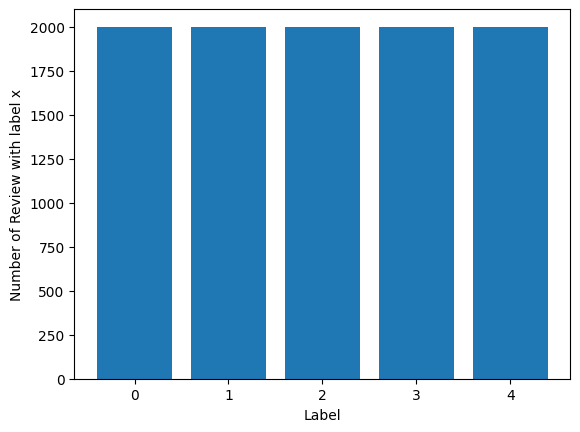

In [ ]:
plt.bar(x=dfSubset['label'].unique(),height=dfSubset['label'].value_counts())
plt.xlabel("Label")
plt.ylabel("Number of Review with label x")
plt.show()

**Train-test-split:** To differentiate the training samples from the actual testing samples.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X, y = dfSubset['text'], dfSubset['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

In [ ]:
y_train.value_counts()

,count
label,
0,1600
3,1600
2,1600
1,1600
4,1600


In [ ]:
X_train.head()
print(X_train.shape)

(8000,)


In [ ]:
print(type(X_train))

<class 'pandas.core.series.Series'>


In [ ]:
X_train_list = X_train.tolist()

**Feature Extraction** - Making use of Tf-Idf Vectorizer

TF-IDF converts each review into a vector where every dimension represents a word's importance.

Value: term frequnecy x inverse Document Frequnecy

Returns a matrix of size (no. of reviews, no of distinct words).

Each cell is the Tf-IDf value for a word.

- A higher value means a term is frequent in a document, but rare in a collection of documents.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train_list)
print(X_train_vectorized)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 658124 stored elements and shape (8000, 25806)>
  Coords	Values
  (0, 25073)	0.16832875483113946
  (0, 10093)	0.022424545625653113
  (0, 2282)	0.032034499517419365
  (0, 4733)	0.052949016612737446
  (0, 10263)	0.027442534507752893
  (0, 20881)	0.04353812685846992
  (0, 11480)	0.03530509174681776
  (0, 16286)	0.0751939012000856
  (0, 3379)	0.08072970104705057
  (0, 25326)	0.10114628515803967
  (0, 15389)	0.1336765487329874
  (0, 9422)	0.03040884194673627
  (0, 1921)	0.06312288394845998
  (0, 886)	0.07223493348872129
  (0, 16417)	0.13752161843580357
  (0, 23141)	0.10330514764142561
  (0, 12195)	0.13358993113581613
  (0, 24776)	0.22029877330899408
  (0, 10059)	0.03496373996951993
  (0, 9465)	0.05937529223865135
  (0, 6890)	0.08091762257444748
  (0, 1949)	0.08562295835331579
  (0, 929)	0.1155474573204307
  (0, 25171)	0.10881453065977274
  (0, 20295)	0.05542286821598848
  :	:
  (7999, 16196)	0.14395712252323417
  (7999, 8116)	0.1

In [ ]:
print("Actual IDF Values: \n")
for i, j in zip(vectorizer.get_feature_names_out(),vectorizer.idf_): #Getting out feature names for transformation,only the Inverse Document Frequency Values
  print(i,":",j)

Streaming output truncated to the last 5000 lines.
sided : 9.29417463229018
sidekick : 9.29417463229018
sidenote : 8.888709524182016
siders : 9.29417463229018
sides : 5.09697268462837
sidetracked : 8.888709524182016
sidewalk : 7.214733090610343
sidewalks : 7.790097235513905
sidewall : 9.29417463229018
sideways : 9.29417463229018
sierra : 8.888709524182016
sift : 9.29417463229018
sifting : 9.29417463229018
sigh : 7.279271611747914
sighed : 8.601027451730232
sighing : 9.29417463229018
sighs : 8.888709524182016
sight : 6.991589539296133
sighted : 8.888709524182016
sightline : 9.29417463229018
sightlines : 9.29417463229018
sights : 8.888709524182016
sightseeing : 8.601027451730232
sign : 4.990109539086009
signage : 7.096950054953959
signal : 7.9078802711702885
signals : 8.601027451730232
signature : 6.3764039002059
signatures : 9.29417463229018
signed : 7.096950054953959
significance : 9.29417463229018
significant : 7.589426540051753
significantly : 7.214733090610343
signing : 7.9078802711

In [ ]:
X_train_vectorized.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X_train_vectorized.shape #no. of reviews, no of unique tokens

(8000, 25806)

In [ ]:
print(vectorizer.vocabulary_) #tells the column no. of each word(token)

{'we': 25073, 'have': 10093, 'been': 2282, 'coming': 4733, 'here': 10263, 'since': 20881, 'it': 11480, 'opened': 16286, 'but': 3379, 'will': 25326, 'not': 15389, 'go': 9422, 'back': 1921, 'after': 886, 'our': 16417, 'three': 23141, 'last': 12195, 'visits': 24776, 'has': 10059, 'gone': 9465, 'downhill': 6890, 'badly': 1949, 'ago': 929, 'were': 25171, 'seated': 20295, 'in': 10945, 'the': 23032, 'trolley': 23692, 'and': 1226, 'then': 23053, 'completely': 4840, 'ignored': 10823, 'for': 8693, '30': 268, 'minutes': 13695, 'there': 23057, 'was': 25003, 'waitress': 24886, 'apparently': 1385, 'she': 20576, 'new': 14795, 'only': 16261, 'had': 9875, 'front': 8933, 'half': 9917, 'finally': 8377, 'went': 25170, 'out': 16422, 'demanded': 6114, 'manager': 13028, 'who': 25261, 'assigned': 1648, 'us': 24424, 'comp': 4784, 'ed': 7236, 'meals': 13328, 'lasagna': 12187, 'very': 24658, 'disappointing': 6496, 'with': 25397, 'hard': 10015, 'noodles': 15345, 'definitely': 6030, 'oven': 16477, 'baked': 1977, '

**Building a Logistic Regression Model**

Serves as a strong interpretable baseline model before moving to complex neural netwrok architecture.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_test_vectorized = vectorizer.transform(X_test.tolist())


Note: we use .transform(), not .fit_transform(), on the test set — the vectorizer's vocabulary and IDF weights are learned only from training data, to avoid `data leakage`.

In [ ]:
reg = LogisticRegression(random_state=0)
reg.fit(X_train_vectorized, y_train)

y_pred = reg.predict(X_test_vectorized)

**Measuring Accuracy and Error Metrics**

Overall accuracy: 56% (random baseline for 5 classes = 20%).

Looking at per-class F1 scores, the model performs best on extreme sentiment — class 0 (1-star, F1=0.71) and class 4 (5-star, F1=0.65) — but struggles on the middle classes (2,3,4-star, F1≈0.46).

This makes sense: extreme reviews use strong, unambiguous sentiment words ("terrible", "amazing"), which TF-IDF captures well. Middle-ground reviews involve nuanced, mixed language that a model ignoring word order can't fully resolve — this is the gap we expect sequence models (LSTM, BERT) to close.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
acc = accuracy_score(y_pred=y_pred,y_true=y_test)
print(f"Logistic Regression Accuracy: {acc:.2f}")

Logistic Regression Accuracy: 0.56


In [ ]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.67      0.76      0.71       400
           1       0.52      0.46      0.49       400
           2       0.47      0.45      0.46       400
           3       0.48      0.44      0.46       400
           4       0.62      0.68      0.65       400

    accuracy                           0.56      2000
   macro avg       0.55      0.56      0.55      2000
weighted avg       0.55      0.56      0.55      2000



**Conclusion:**

Bag of Words does work, but only on extreme and intense samples(ones with a label of 0 or 4).

Not so great on middle labels(1, 2 or 3).